In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import ScalarFormatter
from soph.utils.config_generator import flatten

/home/shikai_q/miniconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def get_runs(project, filters=None, samples=500):
    """Fetch runs from wandb and return a DataFrame with history and varying config columns."""
    api = wandb.Api()
    runs = api.runs(project, filters=filters or {}, order="-created_at")
    rows = []
    for run in runs:
        config = flatten({k: v for k, v in run.config.items() if not k.startswith("_")})
        hist = pd.DataFrame(run.history(samples=samples))
        rows.append({**config, 'history': hist})
    df = pd.DataFrame(rows)
    # Keep only columns that vary across runs (plus history)
    fixed_cols = [c for c in df.columns if c != 'history' and df[c].apply(str).nunique() <= 1]
    df = df.drop(columns=fixed_cols)
    return df

In [4]:
def compute_lower_convex_hull(df, x_key, y_key, reduced=True, tol=1e-2):
    """Compute lower convex hull (minimize both x and y)."""
    all_points = []
    point_to_run_idx = {}
    for run_idx, run in df.iterrows():
        mask = ~np.isnan(run['history'][y_key])
        x_vals = run['history'][x_key][mask].values
        y_vals = run['history'][y_key][mask].values
        for i, (x, y) in enumerate(zip(x_vals, y_vals)):
            all_points.append((x, y))
            point_to_run_idx[(x, y)] = (run_idx, i)
    if len(all_points) < 2:
        return sorted(all_points, key=lambda p: p[0]), point_to_run_idx
    sorted_points = sorted(all_points, key=lambda p: p[0])
    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])
    hull = []
    for point in sorted_points:
        while len(hull) >= 2:
            cross_prod = cross(hull[-2], hull[-1], point)
            if cross_prod <= tol * abs(hull[-1][0] - hull[-2][0]) * abs(point[1] - hull[-2][1]):
                hull.pop()
            else:
                break
        if len(hull) > 0:
            min_y_so_far = min(p[1] for p in hull)
            if point[1] - min_y_so_far > tol * max(min_y_so_far, point[1]):
                continue
        hull.append(point)
    if reduced:
        run_to_points = {}
        for point in hull:
            run_idx, _ = point_to_run_idx[point]
            run_to_points.setdefault(run_idx, []).append(point)
        hull = []
        for points in run_to_points.values():
            x_vals = [p[0] for p in points]
            median_idx = np.argmin([abs(x - np.median(x_vals)) for x in x_vals])
            hull.append(points[median_idx])
    return sorted(hull, key=lambda p: p[0]), point_to_run_idx

In [5]:
filters = {
    'config.ema_steps': 50,
    'config.tag': 'test',
    'config.T': 10000,
}
runs = get_runs("shikai/requential", filters)
runs['P_raw'] = runs['P']
runs = runs[runs['P'].notna()]
runs['P'] = (runs['P'] / 1e6).apply(lambda x: round(x, -int(np.floor(np.log10(abs(x)))) if x != 0 else 0))
runs = runs.sort_values(by=['meta/rule', 'P', 'student_speed'])
print(f'{len(runs)} runs loaded')

73 runs loaded


In [6]:
runs.loc[:, 'history'] = runs['history'].apply(
    lambda hist: pd.DataFrame({k: v for k, v in hist.items()})
)

def set_test_tokens(df, test_tokens, req=True):
    for idx, row in df.iterrows():
        if req:
            df.at[idx, 'history']['K(M)'] = row['history']['K_req'] / np.log(2)
            df.at[idx, 'history']['K(X|M)'] = row['history']['student_loss'] * test_tokens / np.log(2)
            df.at[idx, 'history']['K(M,X)'] = df.at[idx, 'history']['K(M)'] + df.at[idx, 'history']['K(X|M)']
            df.at[idx, 'history']['req_compute'] = 6 * row['P_raw'] * row['history']['student_tokens']
            df.at[idx, 'history']['test_compute'] = 2 * row['P_raw'] * test_tokens
            df.at[idx, 'history']['total_compute'] = df.at[idx, 'history']['req_compute'] + df.at[idx, 'history']['test_compute']
        else:
            df.at[idx, 'history']['K(M)'] = row['history']['K_auc'] / np.log(2)
            df.at[idx, 'history']['K(X|M)'] = row['history']['train_loss'] * test_tokens / np.log(2)
            df.at[idx, 'history']['K(M,X)'] = df.at[idx, 'history']['K(M)'] + df.at[idx, 'history']['K(X|M)']
            df.at[idx, 'history']['req_compute'] = 6 * row['P_raw'] * row['history']['tokens']
            df.at[idx, 'history']['test_compute'] = 2 * row['P_raw'] * test_tokens
            df.at[idx, 'history']['total_compute'] = df.at[idx, 'history']['req_compute'] + df.at[idx, 'history']['test_compute']

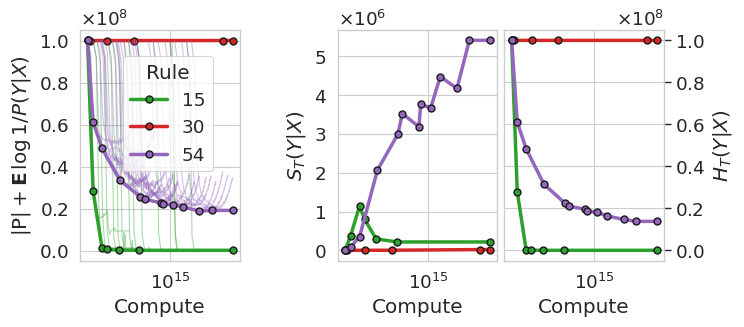

In [7]:
sns.set(style='whitegrid')
sns.set_context("paper", font_scale=1.5)

all_rules = runs['meta/rule'].unique()
x_key = 'total_compute'
test_tokens = 1e8
req = True

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7, 3), sharex=True)

rule_colors = {
    '15': "#2ca02c",
    '54': "#9467bd",
    '30': "#d62728",
}

# Find global max x value across all rules
global_max_x = 0
for rule in sorted(all_rules):
    df_rule = runs[runs['meta/rule'] == rule]
    df_rule = df_rule[df_rule['student_speed'] == 1]
    set_test_tokens(df_rule, test_tokens, req)
    for _, run in df_rule.iterrows():
        mask = ~np.isnan(run['history']['K(M,X)'])
        if mask.any():
            max_x = run['history'][x_key][mask].max()
            global_max_x = max(global_max_x, max_x)

# Plot each rule
for rule in sorted(all_rules):
    df_rule = runs[runs['meta/rule'] == rule]
    df_rule = df_rule[df_rule['student_speed'] == 1]
    set_test_tokens(df_rule, test_tokens, req)
    rule_color = rule_colors.get(str(rule), "#1f77b4")
    pareto_points, point_to_run_idx = compute_lower_convex_hull(df_rule, x_key, 'K(M,X)', reduced=True, tol=2e-2)

    for ax, (y_key, y_label) in zip([ax1, ax2, ax3], [
        ('K(M,X)', r'$|\mathrm{P}| + \mathbf{E}\, \log 1/P(Y|X)$'),
        ('K(M)', r'$S_T(Y|X)$'),
        ('K(X|M)', r'$H_T(Y|X)$')
    ]):
        if ax == ax1:
            for _, run in df_rule.iterrows():
                mask = ~np.isnan(run['history'][y_key])
                x_data = run['history'][x_key][mask]
                y_data = run['history'][y_key][mask]
                if len(x_data) > 100:
                    indices = np.linspace(0, len(x_data) - 1, 100, dtype=int)
                    x_data = x_data.iloc[indices]
                    y_data = y_data.iloc[indices]
                ax.plot(x_data, y_data, c=rule_color, alpha=0.4, linewidth=0.8, mec='k', mew=1)

        pareto_x, pareto_y = [], []
        for pareto_point in pareto_points:
            run_idx, hist_idx = point_to_run_idx[pareto_point]
            run = df_rule.loc[run_idx]
            mask = ~np.isnan(run['history'][y_key])
            masked_indices = np.where(mask)[0]
            if hist_idx < len(masked_indices):
                actual_idx = masked_indices[hist_idx]
                pareto_x.append(run['history'][x_key].iloc[actual_idx])
                pareto_y.append(run['history'][y_key].iloc[actual_idx])

        if pareto_x:
            if len(pareto_x) > 100:
                indices = np.linspace(0, len(pareto_x) - 1, 100, dtype=int)
                pareto_x = [pareto_x[i] for i in indices]
                pareto_y = [pareto_y[i] for i in indices]
            if pareto_x[-1] < global_max_x:
                pareto_x.append(global_max_x)
                pareto_y.append(pareto_y[-1])
            ax.plot(pareto_x, pareto_y, c=rule_color, linewidth=2.5,
                    alpha=1, label=f'{rule}', marker='o', markersize=5, mec='k', mew=1)

        ax.set_ylabel(y_label)
        ax.set_xscale('log')

ax1.set_xlabel('Compute')
ax2.set_xlabel('Compute')
ax3.set_xlabel('Compute')
ax3.yaxis.set_label_position('right')
ax3.yaxis.tick_right()

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, title='Rule', loc='center', bbox_to_anchor=(0.25, 0.6), frameon=True)

pos1 = ax1.get_position()
panel_width = pos1.width
gap_12 = 0.14
gap_23 = 0.01
ax1.set_position([pos1.x0, pos1.y0, panel_width, pos1.height])
ax2.set_position([pos1.x0 + panel_width + gap_12, pos1.y0, panel_width, pos1.height])
ax3.set_position([pos1.x0 + 2*panel_width + gap_12 + gap_23, pos1.y0, panel_width, pos1.height])

for ax in [ax1, ax2, ax3]:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(formatter)

plt.show()